In [1]:
import ee
import geemap
from dotenv import load_dotenv
import os
import ipywidgets as widgets
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd

load_dotenv(dotenv_path='.env')
project_name = os.getenv("project_name")
# print(f"Project Name: {project_name}")
ee.Initialize(project=project_name)

In [18]:
map = geemap.Map()

point = ee.Geometry.Point([90.4152, 23.8041]) #around dhaka
region = ee.Geometry.Rectangle([90.3, 23.7, 90.5, 23.9]) #bounding box around the point

top_left = [23.822424724001266, 90.46289150228976]
bottom_right = [23.796369273111445, 90.5071668854189]

#region = ee.Geometry.Rectangle([top_left[1], bottom_right[0], bottom_right[1], top_left[0]])
region = ee.Geometry.Rectangle([92.12743533806102, 21.81144778755447, 92.56414188102977, 22.207414604160263])

map.centerObject(region, 10)
map.add_basemap('HYBRID')
map.addLayer(point, {'color': 'red'}, 'Point Layer')
map.addLayer(region, {'color': 'blue'}, 'Region Layer')


map.default_style = {'cursor': 'crosshair'}


map #just testing if everything is working

Map(center=[22.009483577149734, 92.34578860954535], controls=(WidgetControl(options=['position', 'transparent_…

In [19]:
landsat = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
  .filterBounds(region) \
  .filterDate('2024-04-01', '2024-06-30') \
  .filter(ee.Filter.lt('CLOUD_COVER', 10)) \
  .median() \
  .clip(region)

In [20]:
#Temp = (Value * 0.00341802) + 149.0
#this value is from https://www.usgs.gov/landsat-missions/landsat-collection-2-surface-temperature
rawTemp = landsat.select('ST_B10')
temp = rawTemp.multiply(0.00341802).add(149.0).subtract(273.15) #in celsius
tempVis = {
    'min': 0,
    'max': 50,
    'palette': ['blue', 'cyan', 'green', 'yellow', 'red']
}

map1 = geemap.Map()
map1.centerObject(region, 10)
map1.addLayer(temp.clip(region), tempVis, 'Surface Temperature °C')
map1

Map(center=[22.009483577149734, 92.34578860954535], controls=(WidgetControl(options=['position', 'transparent_…

In [25]:
countries = ee.FeatureCollection('FAO/GAUL/2015/level0')
bangladesh = countries.filter(ee.Filter.eq('ADM0_NAME', 'Bangladesh'))

new_data = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
  .filterBounds(bangladesh) \
  .filterDate('2024-04-01', '2024-06-30') \
  .filter(ee.Filter.lt('CLOUD_COVER', 10)) \
  .median() \
  .clip(bangladesh)

new_rawTemp = new_data.select('ST_B10')
new_temp = new_rawTemp.multiply(0.00341802).add(149.0).subtract(273.15) #in celsius
        
map2 = geemap.Map()
map2.centerObject(bangladesh, 7)
map2.addLayer(bangladesh, {}, 'Bangladesh')
map2.addLayer(new_temp.clip(bangladesh), tempVis, 'Surface Temperature °C - Bangladesh')
map2

Map(center=[23.8270519912324, 90.28837386710796], controls=(WidgetControl(options=['position', 'transparent_bg…

In [28]:
minMax = new_temp.reduceRegion(
  reducer=ee.Reducer.minMax(),
  geometry=bangladesh,
  scale=30,
  maxPixels=1e9
)

print('min and max surface Temperature in bangladesh:', minMax.getInfo())

min and max surface Temperature in bangladesh: {'ST_B10_max': 74.06097980000004, 'ST_B10_min': -20.884779759999986}


Temperature histogram: {'ST_B10': {'bucketMeans': [-19.658565084999985, -19.191150849999985, -18.751446991428548, -18.20573568399999, -17.835222315999975, -17.229207369999983, -16.665234069999975, -16.241185963749977, -15.80859280749998, -15.19681469999998, -14.816395572949915, -14.302572718947347, -13.693479306249984, -13.270661687199983, -12.748157616982057, -12.211554009999977, -11.732298777142839, -11.286399171187563, -10.748128746999981, -10.191447150271731, -9.776309582748429, -9.237711221935461, -8.75236777229465, -8.214789980714267, -7.774231617142839, -7.2602443661875, -6.7434211504545285, -6.30395671110478, -5.7644898105121545, -5.2722043554999845, -4.8062366689747416, -4.266684475348816, -3.7376643496435835, -3.2385184756540863, -2.756771002631551, -2.223944205454527, -1.7168031719733687, -1.2391081516288704, -0.7480845999999796, -0.25271374715157907, 0.2353112676595994, 0.7434834358490766, 1.2278649044827805, 1.7570070702131249, 2.270325851242222, 2.7746526495522565, 3.2578

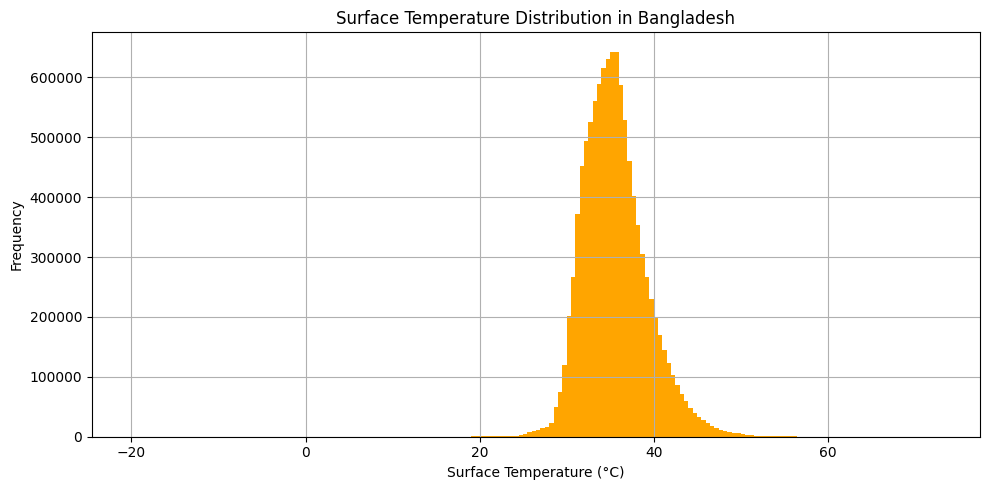

In [34]:
#checking using histogram
histogram = new_temp.reduceRegion(
  reducer=ee.Reducer.histogram(),
  geometry=bangladesh,
  scale=100,
  maxPixels=1e9
)
print('Temperature histogram:', histogram.getInfo())

import matplotlib.pyplot as plt
hist_data = histogram.get('ST_B10').getInfo()
plt.figure(figsize=(10, 5))
plt.bar(hist_data['bucketMeans'], hist_data['histogram'], width=0.5, color='orange')
plt.title('Surface Temperature Distribution in Bangladesh')
plt.xlabel('Surface Temperature (°C)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
'''i don't know the reason why it is giving me -20 to 74 but from the histogram it si clear that most of the values are between
20 and 50 degrees celsius'''